In [1]:
!pip install torch torchvision torchaudio
!pip install git+https://github.com/RobustBench/robustbench.git
!pip install git+https://github.com/fra31/auto-attack
!pip install matplotlib

  Cloning https://github.com/RobustBench/robustbench.git to /tmp/pip-req-build-6oo4l1ul
  Running command git clone --filter=blob:none --quiet https://github.com/RobustBench/robustbench.git /tmp/pip-req-build-6oo4l1ul
  Resolved https://github.com/RobustBench/robustbench.git to commit 78fcc9e48a07a861268f295a777b975f25155964
  Preparing metadata (setup.py) ... done
  Cloning https://github.com/fra31/auto-attack.git (to revision a39220048b3c9f2cca9a4d3a54604793c68eca7e) to /tmp/pip-install-h9zo8won/autoattack_03fde3af229649ca86a757516812d94b
  Running command git clone --filter=blob:none --quiet https://github.com/fra31/auto-attack.git /tmp/pip-install-h9zo8won/autoattack_03fde3af229649ca86a757516812d94b
  Running command git rev-parse -q --verify 'sha^a39220048b3c9f2cca9a4d3a54604793c68eca7e'
  Running command git fetch -q https://github.com/fra31/auto-attack.git a39220048b3c9f2cca9a4d3a54604793c68eca7e
  Resolved https://github.com/fra31/auto-attack.git to commit a39220048b3c9f2cca9a4

# **Run code cells in test_robustbench.ipynb before executing the below cells.**

Eps: 0.0 | ASR Std: 0.0% | ASR Robust: 0.0%
setting parameters for standard version
setting parameters for standard version
using standard version including apgd-ce, apgd-t, fab-t, square.
initial accuracy: 100.00%
apgd-ce - 1/1 - 8 out of 8 successfully perturbed
robust accuracy after APGD-CE: 0.00% (total time 4.4 s)
max Linf perturbation: 0.00784, nan in tensor: 0, max: 1.00000, min: 0.00000
robust accuracy: 0.00%
using standard version including apgd-ce, apgd-t, fab-t, square.
initial accuracy: 100.00%
apgd-ce - 1/1 - 1 out of 8 successfully perturbed
robust accuracy after APGD-CE: 87.50% (total time 2.2 s)
apgd-t - 1/1 - 0 out of 7 successfully perturbed
robust accuracy after APGD-T: 87.50% (total time 21.6 s)
fab-t - 1/1 - 0 out of 7 successfully perturbed
robust accuracy after FAB-T: 87.50% (total time 65.1 s)
square - 1/1 - 0 out of 7 successfully perturbed
robust accuracy after SQUARE: 87.50% (total time 118.4 s)
max Linf perturbation: 0.00784, nan in tensor: 0, max: 1.00000, 

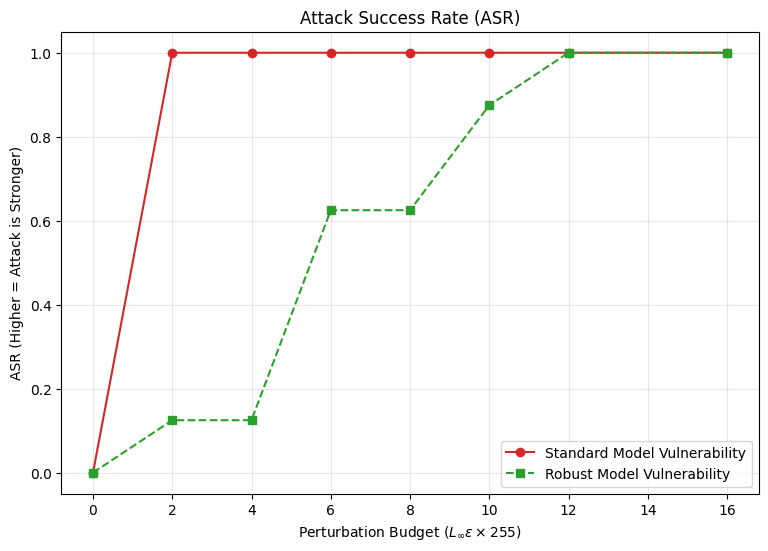

In [22]:
import matplotlib.pyplot as plt
import torch
from autoattack import AutoAttack

#Setup
subset_size = 50
epsilons = [0, 2/255, 4/255, 6/255, 8/255, 10/255, 12/255, 16/255]
asr_model_a, asr_model_b = [], []

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
images_sub = clean_images[:subset_size].to(device)
labels_sub = clean_labels[:subset_size].to(device)

for eps in epsilons:
    if eps == 0:
        asr_model_a.append(0.0)
        asr_model_b.append(0.0)
        print(f"Eps: 0.0 | ASR Std: 0.0% | ASR Robust: 0.0%")
        continue

    att_a = AutoAttack(model_a, norm='Linf', eps=eps, version='standard', device=device, verbose=True)
    att_b = AutoAttack(model_b, norm='Linf', eps=eps, version='standard', device=device, verbose=True)

    with torch.no_grad():
        # Clean predictions to identify initially correct samples
        out_a = model_a(images_sub).max(1)[1]
        out_b = model_b(images_sub).max(1)[1]

        correct_idx_a = (out_a == labels_sub)
        correct_idx_b = (out_b == labels_sub)

        # Run AutoAttack
        _, l_adv_a = att_a.run_standard_evaluation(images_sub, labels_sub, bs=subset_size, return_labels=True)
        _, l_adv_b = att_b.run_standard_evaluation(images_sub, labels_sub, bs=subset_size, return_labels=True)

    # Calculate ASR only for samples that were originally correct
    success_a = correct_idx_a & (l_adv_a != labels_sub)
    success_b = correct_idx_b & (l_adv_b != labels_sub)

    # Use .item() only if it's a tensor, and handle potential division by zero
    val_a = (success_a.float().sum() / correct_idx_a.float().sum()).item() if correct_idx_a.any() else 0.0
    val_b = (success_b.float().sum() / correct_idx_b.float().sum()).item() if correct_idx_b.any() else 0.0

    asr_model_a.append(val_a)
    asr_model_b.append(val_b)

    print(f"Eps: {eps*255:.1f}/255 | ASR Std: {val_a*100:.1f}% | ASR Robust: {val_b*100:.1f}%")


plt.figure(figsize=(9, 6))
plt.plot([e*255 for e in epsilons], asr_model_a, 'o-', color='#d62728', label='Standard Model Vulnerability')
plt.plot([e*255 for e in epsilons], asr_model_b, 's--', color='#2ca02c', label='Robust Model Vulnerability')

plt.title('Attack Success Rate (ASR)')
plt.xlabel(r'Perturbation Budget ($L_{\infty} \epsilon \times 255$)')
plt.ylabel('ASR (Higher = Attack is Stronger)')
plt.ylim(-0.05, 1.05)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

**Key Findings:**


*   The standard model exhibited a 100% Attack Success Rate (ASR) almost immediately, starting at $\epsilon = 2/255$. It was consistently compromised by the first and simplest attack in the ensemble (APGD-CE) in under 5 seconds, confirming a lack of defensive margin.

*   The robust model demonstrated a significantly higher resistance. At the common benchmark of $\epsilon = 8/255$, it maintained a 37.5% Robust Accuracy (62.5% ASR).

*   While the standard model failed instantly, the robust model forced the attacker to utilize the full ensemble. In several cases, it resisted gradient-based attacks (APGD) and only failed when subjected to the computationally expensive Square Attack (black-box), or resisted the entire ensemble altogether.

*  The time required to find an adversarial example was approximately 30x higher for the robust model, highlighting its practical security advantage in real-world scenarios.



<>:38: SyntaxWarning: invalid escape sequence '\e'
<>:38: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipykernel_4882/1541918872.py:38: SyntaxWarning: invalid escape sequence '\e'
  plt.suptitle(f"Adversarial Analysis at $\epsilon$ = {eps*255:.1f}/255", fontsize=14)


Visualizing Standard Model Vulnerabilities (Eps 8/255):


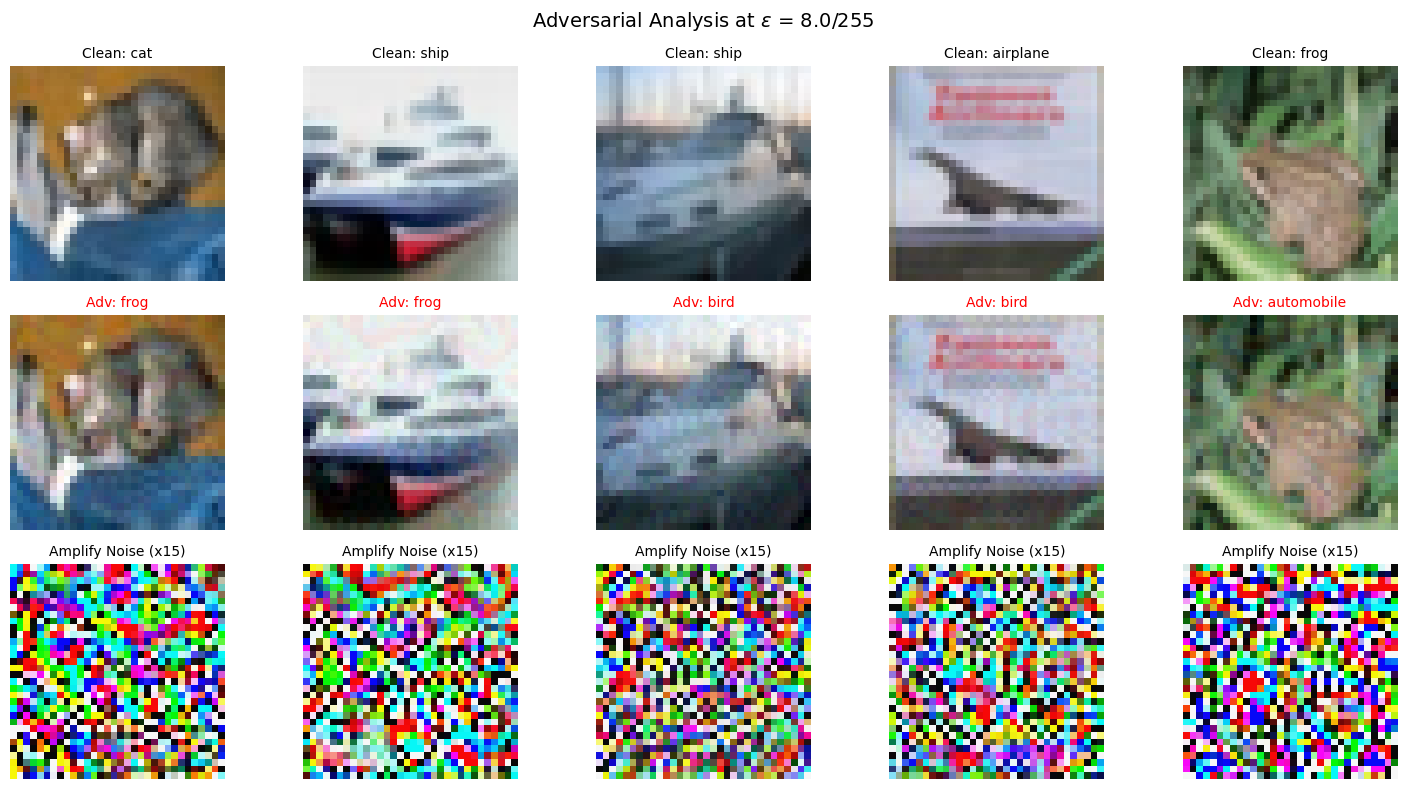

Visualizing Robust Model Defense (Eps 8/255):


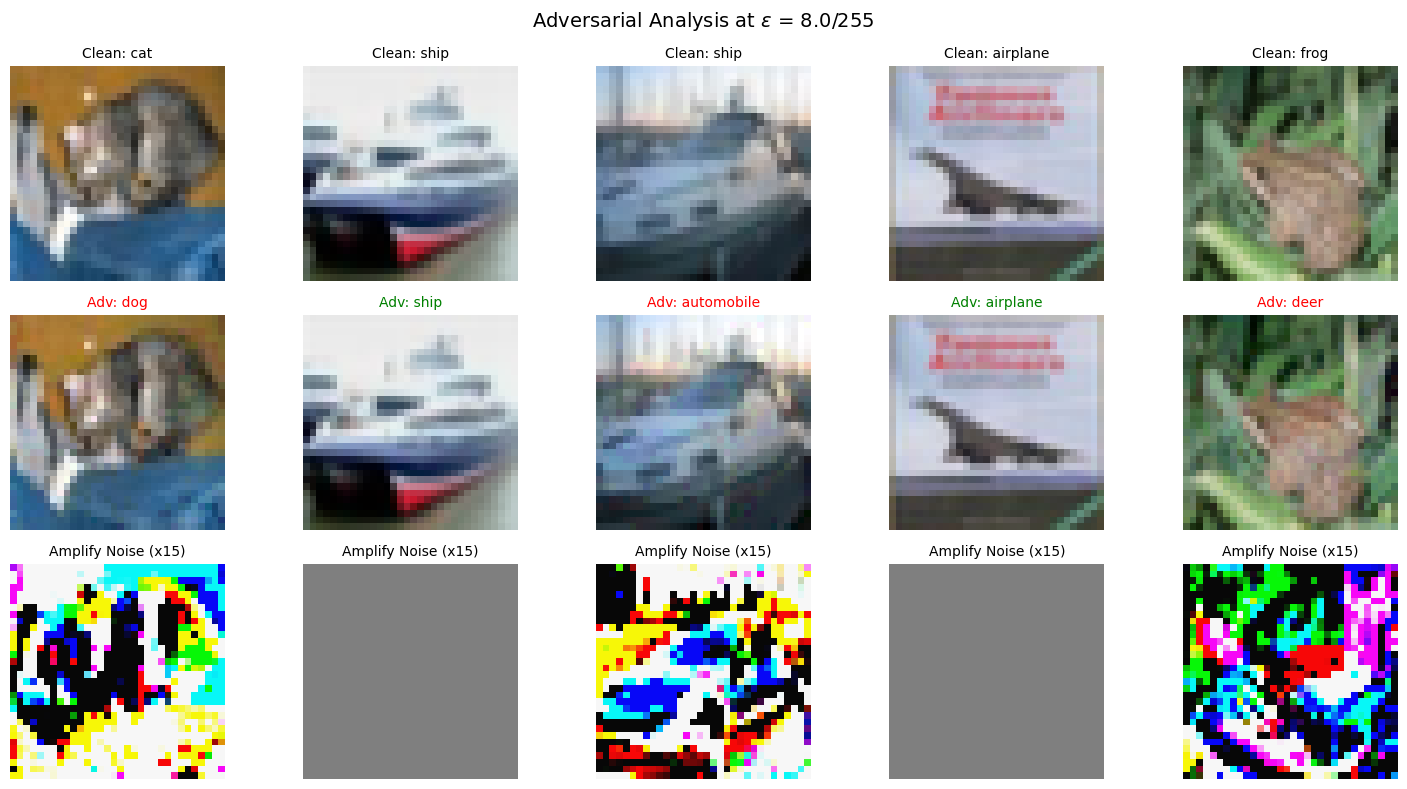

In [27]:
def visualize_adversarial_examples(model, images, labels, eps=8/255, n_display=5):
    images_to_attack = images[:n_display].to(device)
    labels_to_attack = labels[:n_display].to(device)

    attacker = AutoAttack(model, norm='Linf', eps=eps, version='standard', device=device, verbose=False)
    adv_images = attacker.run_standard_evaluation(images_to_attack, labels_to_attack, bs=n_display)

    # Calculate perturbation
    perturbation = adv_images - images_to_attack
    # Amplify noise: 0.5 is the neutral gray for the difference
    amplified_noise = torch.clamp(perturbation * 15 + 0.5, 0, 1)

    def to_np(t):
        return t.permute(1, 2, 0).detach().cpu().numpy()

    fig, axes = plt.subplots(3, n_display, figsize=(n_display * 3, 8))
    classes = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

    for i in range(n_display):
        # Row 1: Clean
        axes[0, i].imshow(to_np(images_to_attack[i]))
        axes[0, i].set_title(f"Clean: {classes[labels_to_attack[i]]}", fontsize=10)
        axes[0, i].axis('off')

        # Row 2: Adversarial
        axes[1, i].imshow(to_np(adv_images[i]))
        with torch.no_grad():
            pred = model(adv_images[i].unsqueeze(0)).argmax().item()
        color = 'red' if pred != labels_to_attack[i] else 'green'
        axes[1, i].set_title(f"Adv: {classes[pred]}", fontsize=10, color=color)
        axes[1, i].axis('off')

        # Row 3: Noise (The "Fingerprint" of the attack)
        axes[2, i].imshow(to_np(amplified_noise[i]))
        axes[2, i].set_title("Amplify Noise (x15)", fontsize=10)
        axes[2, i].axis('off')

    plt.suptitle(f"Adversarial Analysis at $\epsilon$ = {eps*255:.1f}/255", fontsize=14)
    plt.tight_layout()
    plt.show()


print("Visualizing Standard Model Vulnerabilities (Eps 8/255):")
visualize_adversarial_examples(model_a, clean_images, clean_labels, eps=8/255)

print("Visualizing Robust Model Defense (Eps 8/255):")
visualize_adversarial_examples(model_b, clean_images, clean_labels, eps=8/255)

In the visualization above, titles are color-coded to indicate the model's success. Red titles denote successful adversarial attacks where the model was misdirected. Green titles represent a successful defense, where the model's prediction remained consistent with the ground truth despite the perturbation.